## Grape Disease Classification Classification


# 2. Dataset Analysis

### 2.1. Grape Leaf Disease Dataset

🌿 Overview: this dataset contains images of infected and healthy grape leaves, categorized into 4 distinct classes. The primary goal is to enable machine learning models to accurately detect and classify grape plant diseases across three major diseases: Black Measles, Black Rot, Healthy, Isariopsis Leaf Spot
https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset/data    

A detailed breakdown of the disease classes and the distribution of images across the standard training and test splits is provided in the table below, which has been adapted from the original dataset.

| Disease Class | Training Images | Test Images | Total Images |
| :--- | :---: | :---: | :---: |
| Black Rot | 944 | 236 | 1,180 |
| Esca (Black Measles) | 1,106 | 277 | 1,383 |
| Healthy | 338 | 85 | 423 |
| Leaf Blight (Isariopsis Leaf Spot) | 860 | 216 | 1,062 |
| --- | --- | --- | --- |
| **Total Disease Classes** | **4** | **4** | **4** |
| **Total Images** | **3248** | **814** | **4062** |

[*Table 1: Data composition of the 4 grape disease classes. The dataset maintains a relatively balanced distribution across all disease categories, with each class containing approximately 2,000-2,400 images.*]

### 2.2. Exploratory Data Analysis

As indicated by the table in the previous section, the Grape Leaf Disease dataset is well-balanced across its 4 disease classes. This section performs a brief exploratory analysis to confirm the dataset's structure and visualize some of its contents.

The dataset is sourced from the local directory at `/home/ubuntu/GddAi/dd_cnn/dataset/grape-disease/` with separate folders for training and testing data.


Jupyter Notebook is working!
Python version: 3.10.12 (main, Jan  8 2026, 06:52:19) [GCC 11.4.0]
NumPy version: 1.24.4
NumPy calculation: Sum of [1, 2, 3, 4, 5] = 15


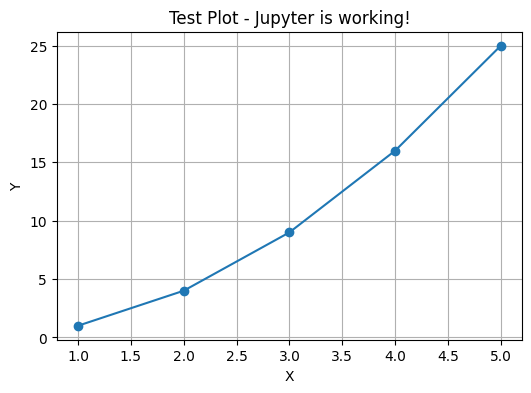

✓ All tests passed! Notebook is ready to use.


In [1]:
# Test to check if Jupyter Notebook is working correctly
import sys
import numpy as np
import matplotlib.pyplot as plt

print("Jupyter Notebook is working!")
print(f"Python version: {sys.version}")
print(f"NumPy version: {np.__version__}")

# Simple test calculation
test_array = np.array([1, 2, 3, 4, 5])
print(f"NumPy calculation: Sum of {list(test_array)} = {test_array.sum()}")

# Simple test plot
plt.figure(figsize=(6, 4))
plt.plot([1, 2, 3, 4, 5], [1, 4, 9, 16, 25], 'o-')
plt.title("Test Plot - Jupyter is working!")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

print("✓ All tests passed! Notebook is ready to use.")

First of all import some libraries that are used throughout the notebook:

In [2]:
# Install missing packages with proper CUDA support
packages_to_check = {
    'gdown': 'gdown',
    'tqdm': 'tqdm',
    'ipywidgets': 'ipywidgets',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'numpy': 'numpy'
}

for package_name, pip_name in packages_to_check.items():
    try:
        if package_name == 'sklearn':
            from sklearn.metrics import confusion_matrix  # Test specific import
        elif package_name == 'matplotlib':
            import matplotlib.pyplot as plt  
        else:
            __import__(package_name)
        print(f"{package_name} already available")
    except ImportError:
        print(f"Installing {pip_name}...")
        !pip install -q {pip_name}

# Check PyTorch and install if missing with auto-detected CUDA support
try:
    import torch
    import torchvision
    print(f"PyTorch {torch.__version__} already installed")
    if torch.cuda.is_available():
        print(f"CUDA {torch.version.cuda} support available")
        print(f"GPU device: {torch.cuda.get_device_name(0)}")
except ImportError:
    print("PyTorch not found. Detecting system CUDA version...")

    # Detect CUDA version
    import subprocess
    cuda_version = None
    try:
        # Try nvidia-smi first
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
        if result.returncode == 0:
            for line in result.stdout.split('\n'):
                if 'CUDA Version:' in line:
                    cuda_version = line.split('CUDA Version:')[1].strip().split()[0]
                    break

        # Try nvcc as backup
        if not cuda_version:
            result = subprocess.run(['nvcc', '--version'], capture_output=True, text=True)
            if result.returncode == 0:
                for line in result.stdout.split('\n'):
                    if 'release' in line.lower():
                        # Extract version like "12.5" from "release 12.5, V12.5.82"
                        cuda_version = line.split('release')[1].split(',')[0].strip()
                        break
    except:
        pass

    # Determine PyTorch index URL based on CUDA version
    if cuda_version:
        major_minor = cuda_version.split('.')[:2]
        cuda_short = ''.join(major_minor)  # "12.5" -> "125", "12.4" -> "124"
        index_url = f"https://download.pytorch.org/whl/cu{cuda_short}"
        print(f"Installing PyTorch with CUDA {cuda_version} support...")
    else:
        index_url = "https://download.pytorch.org/whl/cpu"
        print("CUDA not detected, installing CPU-only PyTorch...")

    !pip install -q torch torchvision torchaudio --index-url {index_url}

# Verify all imports work
print("\nVerifying all imports...")
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch.optim as optim
    from torch.utils.data import DataLoader, Dataset, Subset
    from torch.quantization import fuse_modules, get_default_qconfig, get_default_qat_qconfig, prepare, prepare_qat, convert
    import torch.nn.utils.prune as prune
    import torchvision
    import torchvision.transforms as transforms
    import torchvision.models as models
    from torchvision.models.resnet import ResNet
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    from sklearn.model_selection import train_test_split
    import numpy as np
    
    # Try to import tqdm for notebooks with fallback to regular tqdm
    try:
        from tqdm.notebook import tqdm
        print("Using tqdm.notebook (with progress bar widgets)")
    except ImportError:
        from tqdm import tqdm
        print("Using standard tqdm (ipywidgets not available)")
    
    import datetime
    import copy
    import os
    import gdown
    import random
    import time
    import pandas as pd
    import seaborn as sns
    from sklearn.manifold import TSNE
    from torch.cuda.amp import autocast, GradScaler

    print("All imports successful!")

    # Show system info
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"CUDA version: {torch.version.cuda}")
        print(f"GPU: {torch.cuda.get_device_name(0)}")

except ImportError as e:
    print(f"Import error: {e}")


gdown already available
tqdm already available
ipywidgets already available
seaborn already available
sklearn already available
pandas already available
matplotlib already available
numpy already available
PyTorch 2.2.0+cu121 already installed
CUDA 12.1 support available
GPU device: NVIDIA L4

Verifying all imports...
Using tqdm.notebook (with progress bar widgets)
All imports successful!
PyTorch version: 2.2.0+cu121
CUDA available: True
CUDA version: 12.1
GPU: NVIDIA L4


In [3]:
# Load the raw datasets

try:
    print("loading the dataset...")
    
    # Function to check if file has valid image extension (case-insensitive)
    def is_valid_image_file(filename):
        valid_extensions = ('.jpg', '.jpeg', '.png', '.ppm', '.bmp', '.pgm', '.tif', '.tiff', '.webp')
        return filename.lower().endswith(valid_extensions)
    
    raw_train_val_dataset = torchvision.datasets.ImageFolder(
        root='/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/dataset/grape_dataset/train',
        is_valid_file=is_valid_image_file
    )
    raw_test_dataset = torchvision.datasets.ImageFolder(
        root='/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/dataset/grape_dataset/test',
        is_valid_file=is_valid_image_file
    )

    print("Dataset loaded successfully.")
    print(f"Training samples: {len(raw_train_val_dataset)}")
    print(f"Test samples: {len(raw_test_dataset)}")
    print(f"Classes: {raw_train_val_dataset.classes}")
except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()

loading the dataset...
Dataset loaded successfully.
Training samples: 3248
Test samples: 814
Classes: ['Black_rot', 'Esca', 'Healthy', 'Leaf_blight']


Verifying the number of images loaded by `torchvision` aligns with the figures reported in the original publication ([Mandal & Gouda, 2024](#mandal2024vineyard)). This ensures that the correct and complete dataset.

In [4]:
# Verify the dataset sizes
train_val_size = len(raw_train_val_dataset)
test_size = len(raw_test_dataset)
total_size = train_val_size + test_size

print(f"Verification of Dataset Size:")
print("-" * 30)
print(f"Images in Training & Validation set: {train_val_size}")
print(f"Images in Test set: {test_size}")
print(f"Total images in the dataset: {total_size}")

# The paper's table shows a total of 7349 images.
# The torchvision split uses the same convention.
if train_val_size == 7222 and test_size == 1805:
    print("\n The dataset size matches the official numbers from the paper.")
else:
    print("\n Warning: The dataset size does not match the official numbers.")

Verification of Dataset Size:
------------------------------
Images in Training & Validation set: 3248
Images in Test set: 814
Total images in the dataset: 4062



With the dataset size confirmed, the next step is to visualise some sample images. This will help to get a better appreciation for the fine-grained nature of the classification task.

In [5]:
# Count images per class
from collections import defaultdict

class_counts = defaultdict(int)
for _, label in raw_train_val_dataset:
    class_counts[raw_train_val_dataset.classes[label]] += 1

print("Number of images per class in Train set:")
print("-" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")


test_class_counts = defaultdict(int)
for _, label in raw_test_dataset:
       test_class_counts[raw_test_dataset.classes[label]] += 1
print("\nNumber of images per class in Test set:")
print("-" * 45)
for class_name, count in test_class_counts.items():
 print(f"{class_name}: {count}")

Number of images per class in Train set:
---------------------------------------------
Black_rot: 944
Esca: 1106
Healthy: 338
Leaf_blight: 860

Number of images per class in Test set:
---------------------------------------------
Black_rot: 236
Esca: 277
Healthy: 85
Leaf_blight: 216


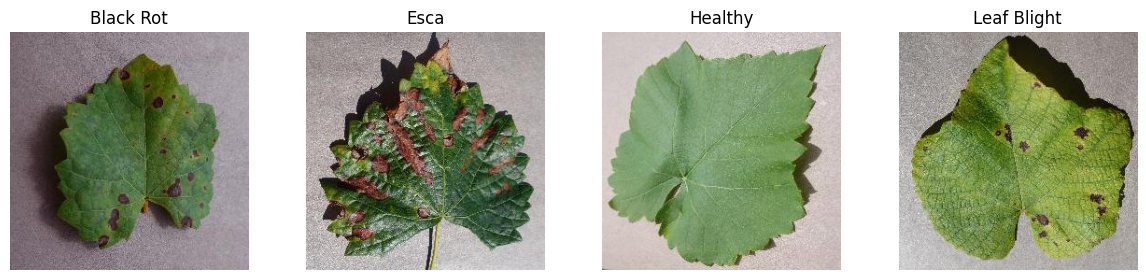

In [6]:
# --- Configuration for the visualization ---
GrapeLeafClasses = 4  
ncols = 4
nrows = int(np.ceil(GrapeLeafClasses / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3 * nrows))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Get the list of class names from the dataset
class_names_train = raw_train_val_dataset.classes
class_names = [name.replace("Grape___", "") for name in class_names_train]
num_classes = len(class_names)

# Find one image for each of the first `GrapeLeafClasses` classes
# This is more efficient than iterating through the whole dataset for each class
class_to_image = {}
for img, label in raw_train_val_dataset:
    if label not in class_to_image and len(class_to_image) < GrapeLeafClasses:
        class_to_image[label] = img
    # Optimization: stop once and you got one image for each required class
    if len(class_to_image) == GrapeLeafClasses:
        break

# Display the images
for i, (label, img) in enumerate(class_to_image.items()):
    ax = axes[i]
    ax.imshow(img)
    # Format title for better readability
    title = class_names[label].replace('_', ' ').title()
    ax.set_title(title)
    ax.axis('off')

# Hide any unused subplots
for i in range(GrapeLeafClasses, len(axes)):
    axes[i].axis('off')


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

Checking the image sizes (heights and widths) across a sample of the training set

In [7]:
# Analyze image sizes from the raw dataset (before resizing)
print("Analyzing original image dimensions...")

# Sample a subset of images to check dimensions
sample_indices = random.sample(range(len(raw_train_val_dataset)), min(100, len(raw_train_val_dataset)))

unique_dimensions = set()
for i in sample_indices:
    img, _ = raw_train_val_dataset[i]  # img is a PIL Image object
    unique_dimensions.add((img.width, img.height))

# Display the results
print(f"\nImage Dimension Analysis (from {len(sample_indices)} samples):")
print("-" * 50)
if len(unique_dimensions) == 1:
    width, height = list(unique_dimensions)[0]
    print(f"All images have uniform dimensions: {width}x{height} pixels")
    print(f"Aspect ratio: {width/height:.2f}")
else:
    print(f"Found {len(unique_dimensions)} different image dimensions:")
    for width, height in sorted(unique_dimensions):
        print(f"  - {width}x{height} pixels (aspect ratio: {width/height:.2f})")


Analyzing original image dimensions...

Image Dimension Analysis (from 100 samples):
--------------------------------------------------
All images have uniform dimensions: 256x256 pixels
Aspect ratio: 1.00


The analysis reveals that all images in the dataset have uniform 256x256 pixel dimensions with 1.0 aspect ratios, meaning they're all square. This consistency simplifies preprocessing since no resizing or cropping is needed, unlike datasets with variable dimensions.

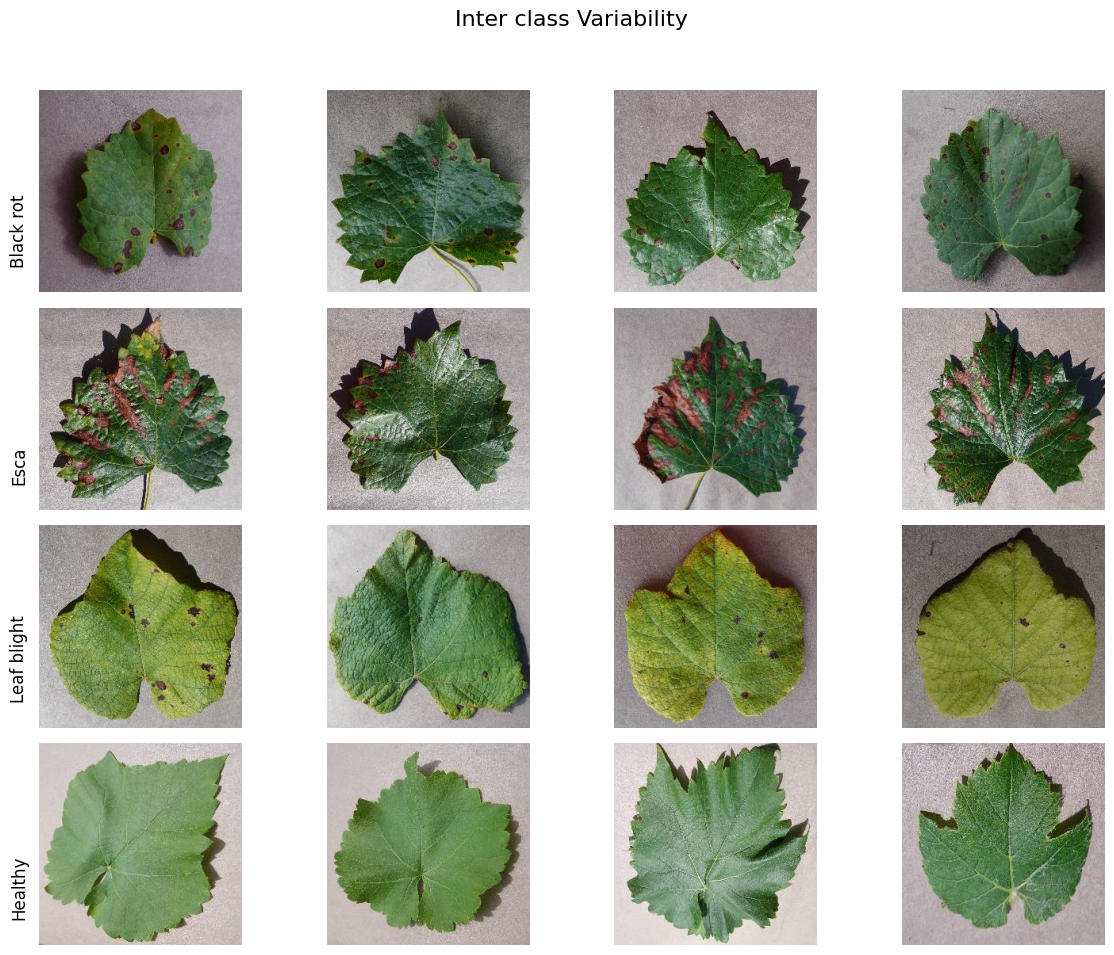

In [8]:
Leaf_class_to_show = ['Black_rot', 'Esca', 'Leaf_blight', 'Healthy']
samples_per_class = 4

# Collect samples for the specified breeds
leaf_images = {Class: [] for Class in Leaf_class_to_show}
class_to_idx = raw_train_val_dataset.class_to_idx

for img, label in raw_train_val_dataset:
    # Reverse lookup to get the class name from the label index
    Class_images = raw_train_val_dataset.classes[label]
    if Class_images in Leaf_class_to_show and len(leaf_images[Class_images]) < samples_per_class:
        leaf_images[Class_images].append(img)

# Plotting 
fig, axes = plt.subplots(len(Leaf_class_to_show), samples_per_class, figsize=(12, 10))
fig.suptitle('Inter class Variability', fontsize=16)

for i, Class_images in enumerate(Leaf_class_to_show):
    for j, img in enumerate(leaf_images[Class_images]):
        ax = axes[i, j]
        ax.imshow(img)
        ax.axis('off')
        if j == 0:
            # Set the leaf disease name as the row title
            ax.set_title(Class_images.replace('_', ' '), rotation=90, x=-0.1, y=0.1, size='large')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 2.3. Data Preprocessing and Augmentation

Data preprocessing and augmentation are essential for training the networks effectively.

Data preprocessing and augmentation strategies vary throughout this project depending on the specific experimental requirements. Rather than presenting all variations upfront, the preprocessing pipeline is detailed at each experimental stage where it is most relevant.

A helper function is defined below to introduce and visualize the preprocessing pipelines throughout the experiments.


In [53]:
class UnNormalize(object):
    """Reverses the normalization on a tensor image for visualization."""
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        """
        Args:
            tensor (Tensor): Tensor image of size (C, H, W) to be unnormalized.
        Returns:
            Tensor: Unnormalized image.
        """
        # Create a copy to avoid modifying the original tensor
        tensor = tensor.clone()
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor

def visualize_transforms(dataset, transform):
    """
    Applies specific transformation types to sample images from each class and displays them with labels.
    Each row represents one image from a different class.
    """
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    un_normalizer = UnNormalize(mean=mean, std=std)

    # Define specific augmentations to visualize with their labels
    augmentations = [
        ("Original", None),
        ("H-Flip", transforms.Compose([
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])),
        ("V-Flip", transforms.Compose([
            transforms.RandomVerticalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])),
        ("Rotation", transforms.Compose([
            transforms.RandomRotation(25),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])),
        ("Color Jitter", transforms.Compose([
            transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.15),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])),
        ("Grayscale", transforms.Compose([
            transforms.RandomGrayscale(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])),
        ("Perspective", transforms.Compose([
            transforms.RandomPerspective(distortion_scale=0.3, p=1.0),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])),
        ("Blur", transforms.Compose([
            transforms.GaussianBlur(kernel_size=3, sigma=(1.0, 1.5)),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])),
        ("Crop+Scale", transforms.Compose([
            transforms.RandomResizedCrop(128, scale=(0.5, 1.0)),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])),
    ]

    # Get one sample from each class
    num_classes = len(dataset.classes)
    indices_per_class = {i: [] for i in range(num_classes)}
    
    # Group indices by class
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        indices_per_class[label].append(idx)
    
    # Select one random image from each class
    selected_indices = []
    for class_idx in sorted(indices_per_class.keys()):
        if indices_per_class[class_idx]:
            random_idx = np.random.choice(indices_per_class[class_idx])
            selected_indices.append(random_idx)

    fig, axes = plt.subplots(num_classes, len(augmentations), 
                             figsize=(2.2 * len(augmentations), 2.5 * num_classes))
    fig.suptitle(title, fontsize=16)

    for i, idx in enumerate(selected_indices):
        original_image, label = dataset[idx]
        class_name = dataset.classes[label]

        for j, (aug_name, aug_transform) in enumerate(augmentations):
            ax = axes[i, j]
            
            if aug_transform is None:
                # Display original with class name
                ax.imshow(original_image)
                ax.set_title(f"{aug_name}\n({class_name})", fontsize=9)
            else:
                # Apply specific augmentation
                augmented_tensor = aug_transform(original_image)
                unnormalized_tensor = un_normalizer(augmented_tensor.clone())
                unnormalized_tensor = torch.clamp(unnormalized_tensor, 0, 1)
                augmented_image_display = unnormalized_tensor.permute(1, 2, 0)
                ax.imshow(augmented_image_display)
                ax.set_title(aug_name, fontsize=9)
            
            ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('augmentation_visualization.png', dpi=600)
    plt.show()

# 3. Global Utilities

Let’s also define a couple global utilities that we will use throughout the notebook:

In [37]:
def evaluate_model(model, data_loader, criterion, device, desc="Evaluating"):
    """A standardized evaluation function to be used across all experiments."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        pbar = tqdm(data_loader, desc=desc)
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=device.type, dtype=torch.float16, enabled=torch.cuda.is_available()):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({
                'Loss': f'{running_loss/total:.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })

    final_loss = running_loss / len(data_loader.dataset)
    final_acc = 100. * correct / total
    return final_loss, final_acc, all_preds, all_labels

def print_model_size(model, label):
    """Saves a model to a temporary file to measure its size on disk."""
    temp_path = f"temp_{label}.pth"
    torch.save(model.state_dict(), temp_path)
    size_mb = os.path.getsize(temp_path) / (1024 * 1024)
    print(f"Size of {label} model: {size_mb:.2f} MB")
    os.remove(temp_path)
    return size_mb

Let’s also define a set of control flags and helper functions for skipping training sections and loading pre-trained results. This allows for faster experimentation by reusing models that have already been trained offline.

In [38]:

# Define some reusable functions to download a file from Google Drive and to load a training history from a CSV file
def download_from_gdrive(file_id, output_path, file_label):
    """Downloads a file from Google Drive if it doesn't already exist."""
    if not os.path.exists(output_path):
        print(f"Downloading {file_label} to '{output_path}'...")
        gdown.download(id=file_id, output=output_path, quiet=False)
        print(f"{file_label} download complete.")
    else:
        print(f"{file_label} file '{output_path}' already exists. Skipping download.")

def load_training_history_from_csv(log_path):
    """Loads a training history log from a CSV file into a dictionary of lists."""
    try:
        log_df = pd.read_csv(log_path)
        # Ensure all expected columns are present, fill with empty lists if not
        history = {
            'train_loss': log_df.get('train_loss', pd.Series([])).tolist(),
            'train_accuracy': log_df.get('train_accuracy', pd.Series([])).tolist(),
            'val_loss': log_df.get('val_loss', pd.Series([])).tolist(),
            'val_accuracy': log_df.get('val_accuracy', pd.Series([])).tolist(),
            'learning_rate': log_df.get('learning_rate', pd.Series([])).tolist()
        }
        if history['train_loss']:
             print(f"Successfully loaded training history for {len(history['train_loss'])} epochs from '{log_path}'.")
        else:
             print(f"Warning: Could not load complete history from '{log_path}'. Check file content.")
        return history
    except FileNotFoundError:
        print(f"Error: The log file '{log_path}' was not found.")
        # Return empty history to avoid crashing subsequent code
        return {key: [] for key in ['train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'learning_rate']}

To ensure that our experimental results are consistent and can be reliably reproduced, we now set a global random seed.

The `set_seed` function:
* Sets the seed for Python's built-in `random` module and NumPy, in order to have some deterministic behavior.
* For PyTorch (and also GPU operations), we do not enforce a fully deterministic strategy, because we want to keep a good balance between execution reproducibility and performance.

We then call this function immediately to apply these settings for the remainder of the notebook.

In [39]:
# We ensure reproducibility in our experiments
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    print(f"Random seed set to {seed}")

# Set the seed for the entire notebook
SEED = 42
set_seed(SEED)

Random seed set to 42


## 4. Transfer Learning: Fine-tuned MobileNet

Instead of initialising our model's weights randomly, we can employ **transfer learning**. As this technique was introduced during the course's practical laboratories, we will provide a concise overview here. The core idea is that of starting from a model that has already been trained on a very large dataset, such as ImageNet, which contains millions of images across a thousand classes. This "pre-trained" model has already learned to recognise a rich hierarchy of general visual features – from simple edges and textures in its early layers to more complex patterns and object parts in its later layers.

By using these pre-trained weights as a starting point, we can provide a model with a significant head start. This approach typically leads to faster convergence and superior performance, as the model only needs to "fine-tune" its existing knowledge for our specific, downstream task of classifying grape diseases, rather than learning everything from scratch. For this section, we will use **MobileNet**, an efficient architecture specifically designed for mobile and embedded devices, making it ideal for deployment on resource-constrained platforms like the ESP32.

#### 4.1. A Two-Stage Fine-Tuning Strategy

This implementation follows a two-stage methodology designed to maximise performance and stability:

1.  **Stage 1: Feature Extraction (Warm-up)**
    All layers of the pre-trained MobileNet model are frozen and the final classification layer is replaced with a new one for the 4 grape disease classes. Training only this new classifier head allows it to learn task-specific features without corrupting the pre-trained weights.

2.  **Stage 2: Full Fine-Tuning**
    After warming up the classifier, the entire network is unfrozen and all layers are fine-tuned with a reduced learning rate. This allows the model to adapt its learned features specifically for grape disease classification while maintaining the valuable representations learned from ImageNet.

In [40]:
# MobileNet Fine-Tuning Configuration
# ==========================================
# ESP32-S3 OPTIMIZED FINE-TUNING CONFIG
# ==========================================
# Fine-tuning from ImageNet weights should converge faster
# ==========================================

NUM_CLASSES = 4
BATCH_SIZE = 64  # Training batch size (ESP32 uses batch_size=1 for inference)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Stage 1: Warm-up (Training the classifier head only)
STAGE1_EPOCHS = 20       # 20 epochs for warm-up
STAGE1_LR = 1e-5         # Higher LR for new classifier head
STAGE1_PATIENCE = 5     # Early stopping patience
STAGE1_MODEL_PATH_MN = "transfer_learning_128.pth"

# Stage 2: Full Fine-tuning (All layers unfrozen)
STAGE2_EPOCHS = 80      # 80 epochs for full fine-tuning
STAGE2_LR = 1e-6         # Lower LR for fine-tuning pretrained weights
STAGE2_PATIENCE = 15     # More patience for fine-tuning
STAGE2_MODEL_PATH_MN = "finetuned_mobilenet_128.pth"

# Regularization
LABEL_SMOOTHING_FT = 0.1    # Label smoothing for better generalization
WEIGHT_DECAY_FT = 1e-6      # L2 regularization



In [41]:
# Define a wrapper class to apply transforms to a Subset
# This is needed because torch.utils.data.random_split returns a Subset object
# which doesn't directly support transformations

class TransformedSubset(Dataset):
    """
    Wrapper class to apply transforms to a Subset.
    
    Args:
        subset: A torch.utils.data.Subset object
        transform: Optional transform to be applied on a sample
    """
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    
    def __len__(self):
        return len(self.subset)
    
    @property
    def classes(self):
        return self.subset.dataset.classes

print("TransformedSubset class defined successfully.")

TransformedSubset class defined successfully.


For transfer learning, it is best practice to use the specific preprocessing pipeline that the model was originally trained on. The `torchvision` library makes this easy by providing these transforms alongside the pre-trained weights. We will also add `TrivialAugmentWide` for data augmentation during training.

The rest of the cell mirrors the data loading logic from the first experiment. It creates the same reproducible train/validation split and instantiates the `DataLoader`s that will be used during the fine-tuning process.

In [49]:
# Data preparation for fine-tuning
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)
    @property
    def classes(self):
        return self.subset.dataset.classes

# ==========================================
# ESP32-S3 OPTIMIZED TRANSFORMS FOR FINE-TUNING
# ==========================================
# Using 128x128 input size (optimal for ESP32 deployment)
# ImageNet normalization is maintained for transfer learning
# ==========================================

# Training transforms with strong augmentation
train_transform_ft = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.5, 0.8)), # Aggressive random crop and resize to 128x128 and maintain aspect ration and random scale
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.6),
    transforms.RandomRotation(25, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.65, hue=0.45),
    transforms.RandomGrayscale(p=0.15),
    transforms.RandomPerspective(distortion_scale=0.9, p=0.7),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3))
])

# Validation/Test transforms (no augmentation)
test_transform_ft = transforms.Compose([
    transforms.Resize(144),  # Slightly larger than 128 for center crop
    transforms.CenterCrop(128),  # 128x128 for ESP32 deployment
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("--- Validation/Test Transforms ---")
print(test_transform_ft)

print("\n--- Training Transforms (with Augmentation) ---")
print(train_transform_ft)


# Load the grape disease dataset from local directory
train_dir = '/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/dataset/grape_dataset/train'
test_dir = '/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/dataset/grape_dataset/test'

# Load training-validating and testing datasets from local folders
raw_train_val_dataset = torchvision.datasets.ImageFolder(root=train_dir, transform=None)
raw_test_dataset = torchvision.datasets.ImageFolder(root=test_dir, transform=None)

print(f"\nDataset loaded from local directory:")
print(f"Training/Validation set: {len(raw_train_val_dataset)} images")
print(f"Test set: {len(raw_test_dataset)} images")
print(f"Classes: {raw_train_val_dataset.classes}")

# Create deterministic splits (using same seed as training from scratch for consistency)
# 85-15 split for training and validation of the training set
#Get Labels
targets = [s[1] for s in raw_train_val_dataset.samples]
# Stratified split
train_idx, val_idx = train_test_split(
    list(range(len(targets))),
    test_size=0.15,
    stratify=targets,
    random_state=42
)
# Create Train and Validation subsets
from torch.utils.data import Subset
train_subset = Subset(raw_train_val_dataset, train_idx)
val_subset = Subset(raw_train_val_dataset, val_idx)


# Apply transforms to subsets
train_dataset_ft = TransformedSubset(train_subset, train_transform_ft)
val_dataset_ft = TransformedSubset(val_subset, test_transform_ft)
test_dataset_ft = TransformedSubset(raw_test_dataset, test_transform_ft)

# Create a dataset for visualization that has NO transforms
raw_test_dataset_for_viz = torchvision.datasets.ImageFolder(root=test_dir, transform=None)

# Create DataLoaders
train_loader_ft = DataLoader(train_dataset_ft, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader_ft = DataLoader(val_dataset_ft, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader_ft = DataLoader(test_dataset_ft, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"\n Dataset Split Summary:")
print(f"   Train: {len(train_dataset_ft)} images ({len(train_loader_ft)} batches)")
print(f"   Validation: {len(val_dataset_ft)} images ({len(val_loader_ft)} batches)")
print(f"   Test: {len(test_dataset_ft)} images ({len(test_loader_ft)} batches)")
print(f"   Classes: {raw_train_val_dataset.classes}")
print(f"\n DataLoaders created successfully.")

--- Validation/Test Transforms ---
Compose(
    Resize(size=144, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(128, 128))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

--- Training Transforms (with Augmentation) ---
Compose(
    RandomResizedCrop(size=(128, 128), scale=(0.5, 0.8), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.6)
    RandomRotation(degrees=[-25.0, 25.0], interpolation=bilinear, expand=False, fill=0)
    ColorJitter(brightness=(0.5, 1.5), contrast=(0.5, 1.5), saturation=(0.35, 1.65), hue=(-0.45, 0.45))
    RandomGrayscale(p=0.15)
    RandomPerspective(p=0.7)
    GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.5))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0, inplace=False)
)

Dataset loaded from local directory:
Training

Now, let's visualize the second pipeline, which uses `TrivialAugmentWide`. This is a modern auto-augmentation policy that applies a wide range of distortions, including shearing, color inversion, and posterization, providing a powerful and diverse set of training examples.

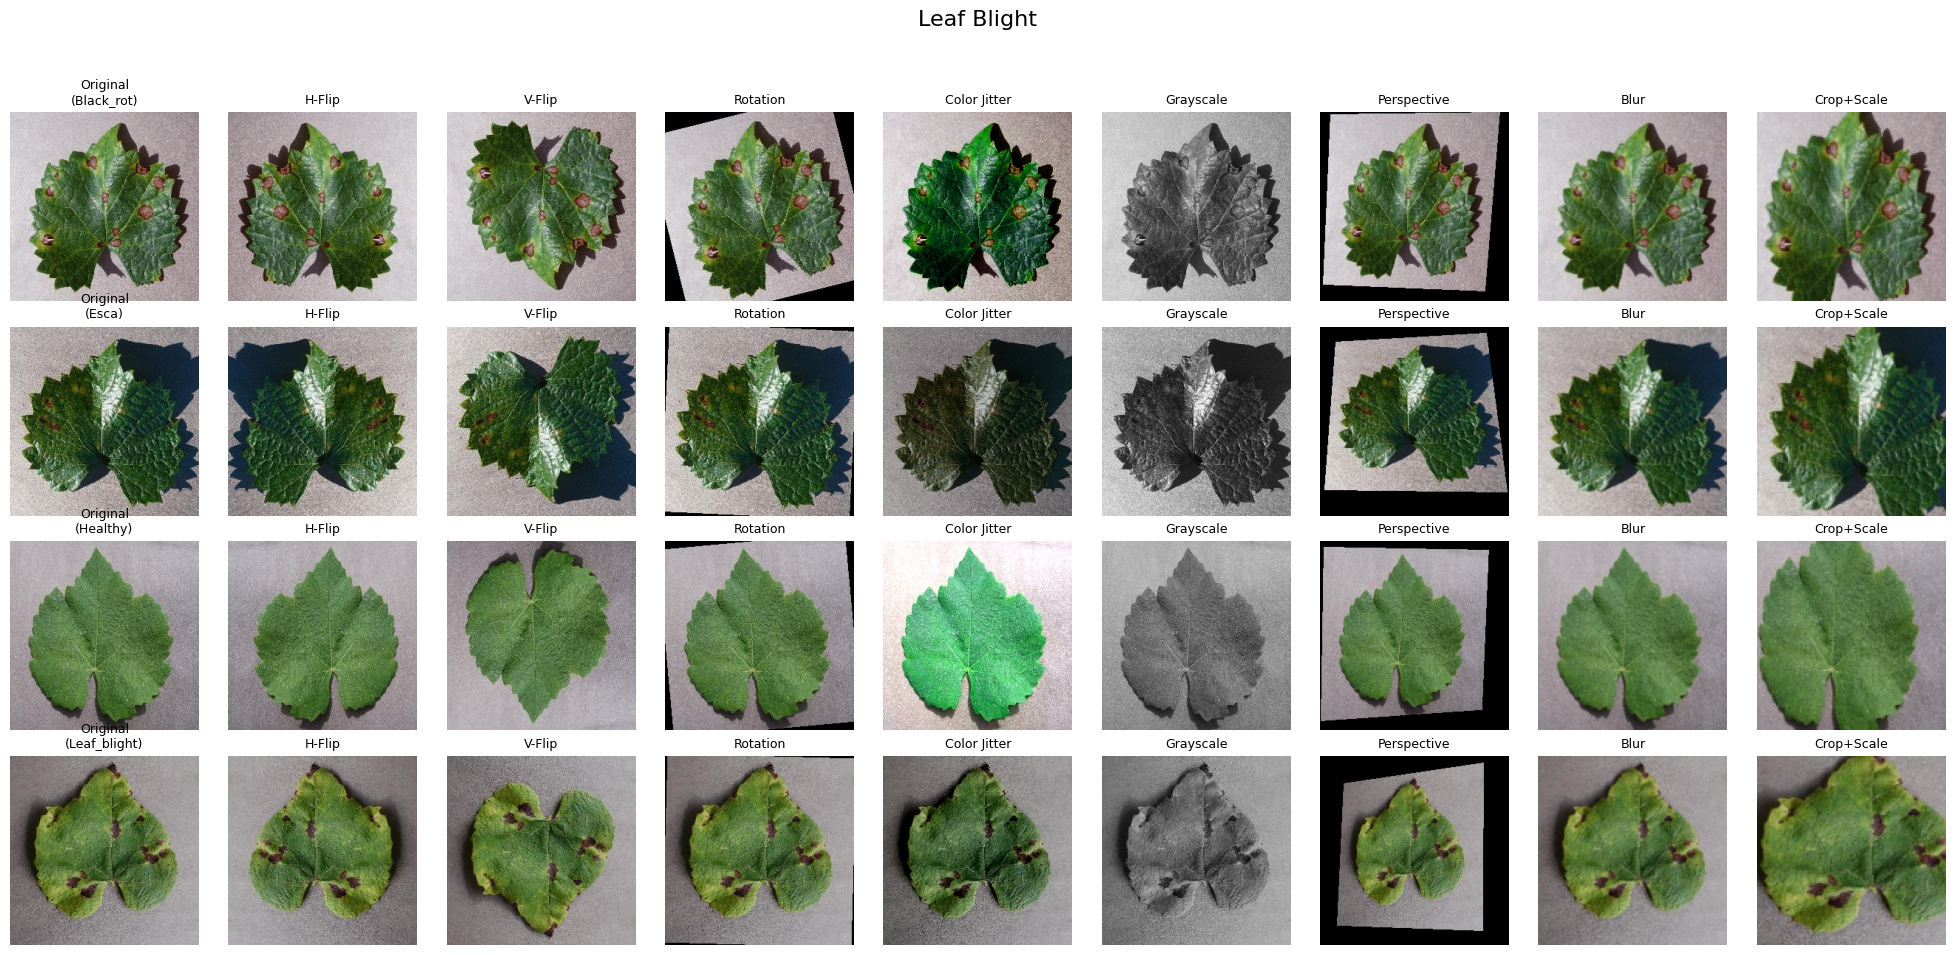

In [54]:
# Visualize the "Transfer Learning" augmentations
visualize_transforms(
    dataset=raw_train_val_dataset,
    transform=train_transform_ft
)

We now define our `FineTuneMobileNet` model, which is structured to facilitate our two-stage training approach. The initialization performs three steps:

1.  **Load Pre-trained Weights**: It loads a MobileNetV2 model using the `.DEFAULT` weights, which are pre-trained on ImageNet. This provides a strong foundation of learned visual features optimized for efficiency.
2.  **Freeze the Backbone**: All parameters of the pre-trained model are frozen by setting `requires_grad=False`. This protects the learned weights from being corrupted by large gradients from the untrained classifier head during the initial training phase.
3.  **Replace the Classifier**: The original 1000-class ImageNet classifier is replaced with a new, trainable classifier adjusted to our 4-class grape disease problem.

The class also includes a useful `unfreeze_all` method to make all parameters trainable for the second stage of fine-tuning.

In [39]:
# We define the model to fine-tune
class FineTuneMobileNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.2):
        super().__init__()
        # 1. Load the MobileNetV2 model with the best available pretrained weights
        weights = torchvision.models.MobileNet_V2_Weights.DEFAULT
        self.mobilenet = torchvision.models.mobilenet_v2(weights=weights)

        # 2. Freeze all parameters in the pretrained backbone
        for param in self.mobilenet.parameters():
            param.requires_grad = False

        # 3. Replace the final classifier with a new head
        # MobileNetV2's classifier is at self.mobilenet.classifier
        in_features = self.mobilenet.classifier[1].in_features  # 1280 for MobileNetV2
        self.mobilenet.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.mobilenet(x)

    def unfreeze_all(self):
        """A helper method to unfreeze all layers for the second stage of training."""
        print("Unfreezing all model layers for fine-tuning...")
        for param in self.mobilenet.parameters():
            param.requires_grad = True

model_ft_mn = FineTuneMobileNet(num_classes=NUM_CLASSES).to(DEVICE)

# Verify which parameters are trainable
trainable_params = sum(p.numel() for p in model_ft_mn.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_ft_mn.parameters())
print(f"Initially, only the classifier head is trainable.")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")

Initially, only the classifier head is trainable.
Trainable parameters: 5,124
Total parameters: 2,228,996


To manage the two-stage training, we define a training loop and an early stopping utility. This loop is simpler than the one used for training from scratch, as we have found advanced techniques like mixed-precision to be less critical for fine-tuning.

* **`EarlyStopper` Class**: This helper class monitors the validation loss during training. It saves a checkpoint of the model whenever a new best (i.e. lower) validation loss is achieved and will stop the training run if the performance does not improve for a set number of epochs (patience).
* **`train_validate_loop_ft` Function**: This function contains the complete logic for one stage of training.

In [40]:
# early-stopping mechanism implementation
class EarlyStopper:
    """Handles early stopping and saves the best model based on validation loss."""
    def __init__(self, patience=7, min_delta=0, model_save_path="best_model.pth", min_relative_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta  # Absolute minimum improvement
        self.min_relative_delta = min_relative_delta  # Relative improvement (e.g., 0.1% = 0.001)
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.model_save_path = model_save_path

    def __call__(self, val_loss, model):
        # Use relative improvement when loss is very small, absolute otherwise
        if self.best_loss < 0.01:  # For very small losses, use relative improvement
            improvement_threshold = self.best_loss * (1 - self.min_relative_delta)
            is_improvement = val_loss < improvement_threshold
        else:  # For larger losses, use absolute improvement
            is_improvement = val_loss < self.best_loss - self.min_delta
        
        if is_improvement:
            improvement_pct = ((self.best_loss - val_loss) / max(self.best_loss, 1e-8)) * 100
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.model_save_path)
            print(f"New best model saved with validation loss: {val_loss:.4f} (improved by {improvement_pct:.2f}%)")
        else:
            self.counter += 1
            print(f"No improvement for {self.counter}/{self.patience} epochs. Best loss: {self.best_loss:.4f}")
            if self.counter >= self.patience:
                print("--- Early stopping triggered! ---")
                self.early_stop = True

# training and validation loop
def train_validate_loop_ft(model, train_loader, val_loader, optimizer, criterion, scheduler, num_epochs, early_stopper, device):
    """A complete training and validation loop for one stage of fine-tuning."""
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # training
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        pbar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]")
        for inputs, labels in pbar_train:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        epoch_train_loss = train_loss / train_total
        epoch_train_acc = 100 * train_correct / train_total
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)

        # validation
        epoch_val_loss, epoch_val_acc, _, _ = evaluate_model(model, val_loader, criterion, device, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]")
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        print(f"Epoch {epoch+1} | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}% | Val Loss: {epoch_val_loss:.4f}")

        scheduler.step(epoch_val_loss)
        early_stopper(epoch_val_loss, model)
        if early_stopper.early_stop:
            break

    return history

Now, execute the two training stages.


First, **Stage 1 (Warm-up)** begins. Configure an optimizer that targets *only* the parameters of the new classifier head and then call our `train_validate_loop_ft` function. This allows the new head to learn from the powerful features of the frozen backbone.

Next, **Stage 2 (Full Fine-tuning)** starts. load the best model from Stage 1 and unfreeze the entire network. A new optimizer is configured with a reduced learning rate to train the entire model end-to-end, allowing it to adapt its pre-trained knowledge to our grape disease classification task.


In [41]:
# fine-tuning execution, train stage1 and train stage2:

# History lists
history_stage1_mn, history_stage2_mn = {}, {}

print("Starting MobileNet fine-tuning...")

# Stage 1: Warm-up
print("\n" + "="*70)
print("STAGE 1: TRAINING CLASSIFIER HEAD ONLY")
print("="*70)
print(f"Learning Rate: {STAGE1_LR}")
print(f"Weight Decay: {WEIGHT_DECAY_FT}")
print(f"Label Smoothing: {LABEL_SMOOTHING_FT}")
print(f"Early Stopping Patience: {STAGE1_PATIENCE}")
print()

criterion_ft = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING_FT)

optimizer_stage1_mn = optim.AdamW(model_ft_mn.mobilenet.classifier.parameters(), lr=STAGE1_LR, weight_decay=WEIGHT_DECAY_FT)
scheduler_stage1_mn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_stage1_mn, 'min', factor=0.1, patience=2)
stopper_stage1_mn = EarlyStopper(patience=STAGE1_PATIENCE, model_save_path=STAGE1_MODEL_PATH_MN)

history_stage1_mn = train_validate_loop_ft(
    model_ft_mn, train_loader_ft, val_loader_ft, optimizer_stage1_mn, criterion_ft, scheduler_stage1_mn,
    num_epochs=STAGE1_EPOCHS, early_stopper=stopper_stage1_mn, device=DEVICE
)

# Stage 2: Full fine-tuning
print("\n" + "="*70)
print("STAGE 2: FULL FINE-TUNING (ALL LAYERS)")
print("="*70)
print(f"Loading best model from Stage 1: {STAGE1_MODEL_PATH_MN}")
model_ft_mn.load_state_dict(torch.load(STAGE1_MODEL_PATH_MN))
model_ft_mn.unfreeze_all()

print(f"Learning Rate: {STAGE2_LR} (reduced for fine-tuning)")
print(f"Weight Decay: {WEIGHT_DECAY_FT}")
print(f"Label Smoothing: {LABEL_SMOOTHING_FT}")
print(f"Early Stopping Patience: {STAGE2_PATIENCE}")

# Verify all parameters are trainable
trainable_params = sum(p.numel() for p in model_ft_mn.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_ft_mn.parameters())
print(f"\nTrainable parameters: {trainable_params:,} / {total_params:,} (100%)")
print()

# Use STAGE2_LR constant instead of hardcoded value
optimizer_stage2_mn = optim.AdamW(model_ft_mn.parameters(), lr=STAGE2_LR, weight_decay=WEIGHT_DECAY_FT)
scheduler_stage2_mn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_stage2_mn, 'min', factor=0.2, patience=3)
stopper_stage2_mn = EarlyStopper(patience=STAGE2_PATIENCE, model_save_path=STAGE2_MODEL_PATH_MN)

history_stage2_mn = train_validate_loop_ft(
    model_ft_mn, train_loader_ft, val_loader_ft, optimizer_stage2_mn, criterion_ft, scheduler_stage2_mn,
    num_epochs=STAGE2_EPOCHS, early_stopper=stopper_stage2_mn, device=DEVICE
)

Starting MobileNet fine-tuning...

STAGE 1: TRAINING CLASSIFIER HEAD ONLY
Learning Rate: 0.001
Weight Decay: 0.0001
Label Smoothing: 0.1
Early Stopping Patience: 10



Epoch 1/50 [Training]:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 1/50 [Validation]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1 | Train Acc: 63.91% | Val Acc: 90.37% | Val Loss: 0.6394
New best model saved with validation loss: 0.6394 (improved by nan%)


Epoch 2/50 [Training]:   0%|          | 0/44 [00:00<?, ?it/s]

...

Epoch 128/300 [Validation]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 128 | Train Acc: 98.91% | Val Acc: 100.00% | Val Loss: 0.3553
No improvement for 29/30 epochs. Best loss: 0.3550


Epoch 129/300 [Training]:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 129/300 [Validation]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 129 | Train Acc: 98.95% | Val Acc: 100.00% | Val Loss: 0.3565
No improvement for 30/30 epochs. Best loss: 0.3550
--- Early stopping triggered! ---


Finally, we load the best model from the fine-tuning stage and evaluate its performance on the unseen test set:

In [42]:
print("\n" + "="*70)
print("FINAL EVALUATION ON TEST SET")
print("="*70)
print(f"Loading best model from Stage 2: {STAGE2_MODEL_PATH_MN}")
model_ft_mn.load_state_dict(torch.load(STAGE2_MODEL_PATH_MN))

criterion_ft = nn.CrossEntropyLoss()

# Use the global evaluation function
final_test_loss, final_test_acc, all_preds, all_labels = evaluate_model(
    model_ft_mn, test_loader_ft, criterion_ft, DEVICE, desc="Testing MobileNet"
)

print(f"\n" + "="*70)
print(f"📊 MOBILENET FINE-TUNING RESULTS")
print("="*70)
print(f"Final Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.2f}%")
print(f"\nModel saved as: {STAGE2_MODEL_PATH_MN}")
print(f"Input size: 128x128 (ESP32-optimized)")
print(f"Ready for quantization and ESP32 deployment!")
print("="*70)


FINAL EVALUATION ON TEST SET
Loading best model from Stage 2: finetuned_mobilenet_128.pth


Testing MobileNet:   0%|          | 0/13 [00:00<?, ?it/s]


📊 MOBILENET FINE-TUNING RESULTS
Final Test Loss: 0.0836
Final Test Accuracy: 99.88%

Model saved as: finetuned_mobilenet_128.pth
Input size: 128x128 (ESP32-optimized)
Ready for quantization and ESP32 deployment!


**Analysis:**

As anticipated, transfer learning provides a substantial performance boost. The fine-tuned MobileNet leverages pre-trained ImageNet features to achieve strong classification performance on our grape disease dataset.

This result validates our two-stage fine-tuning strategy – first training the new classifier head and then fine-tuning the entire network with a reduced learning rate – providing an efficient and effective approach for edge deployment.

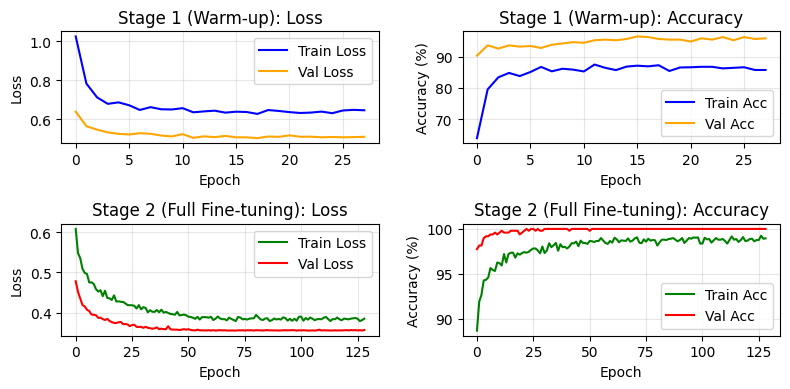

Training curves saved as 'mobilenet_training_curves.png'


In [49]:
# Visualize MobileNet Training Progress

# Plot Stage 1 and Stage 2 training curves
fig, axes = plt.subplots(2, 2, figsize=(8, 4))

# Stage 1: Loss
axes[0, 0].plot(history_stage1_mn['train_loss'], label='Train Loss', color='blue')
axes[0, 0].plot(history_stage1_mn['val_loss'], label='Val Loss', color='orange')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Stage 1 (Warm-up): Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Stage 1: Accuracy
axes[0, 1].plot(history_stage1_mn['train_acc'], label='Train Acc', color='blue')
axes[0, 1].plot(history_stage1_mn['val_acc'], label='Val Acc', color='orange')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Stage 1 (Warm-up): Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Stage 2: Loss
axes[1, 0].plot(history_stage2_mn['train_loss'], label='Train Loss', color='green')
axes[1, 0].plot(history_stage2_mn['val_loss'], label='Val Loss', color='red')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Stage 2 (Full Fine-tuning): Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Stage 2: Accuracy
axes[1, 1].plot(history_stage2_mn['train_acc'], label='Train Acc', color='green')
axes[1, 1].plot(history_stage2_mn['val_acc'], label='Val Acc', color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_title('Stage 2 (Full Fine-tuning): Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mobilenet_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training curves saved as 'mobilenet_training_curves.png'")


OVERFITTING ANALYSIS

MobileNet Fine-Tuned Performance:
  Final Training Accuracy:   98.95%
  Final Test Accuracy:       99.88%

  Train-Val Gap:  -1.05%  Good
  Val-Test Gap:   +0.12%  Good generalization

 Interpretation:
  Excellent! Test accuracy is very high - model generalizes well.


In [50]:
import os

# Model pathsn
models = {
    'pth model': '/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/Model_training/finetuned_mobilenet_128.pth',
    'onnx model': '/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/Model_training/esp32_quantized_models/mobilenetv2_128_fp32.onnx',
    'espdl model': '/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/Model_training/esp32_quantized_models/quantized/mobilenetv2_128_grape_leaf.espdl'
}

print("Model                  Size (MB)")
print("-" * 55)
for name, path in models.items():
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        # Add test accuracy when available
        print(f"{name:<20} {size_mb:>8.2f}")
    else:
        print(f"{name:<20} NOT FOUND")

Model                  Size (MB)
-------------------------------------------------------
pth model                8.75
onnx model               8.47
espdl model              2.26
